# Textract
<p align="center">
  <img src="assets/extraction_submission__.svg" alt="Logo" />
</p>


In [16]:
import boto3
import time
import dotenv
import os
import certifi
import textractcaller as tc

# Load environment variables from .env file
dotenv.load_dotenv(override=True)

True

In [ ]:

bucket = "bucket-name"
document = "data/processed_pdf/WO2020245233A1.pdf"


In [2]:
%%skip
#---------Upload--------#

s3_client = boto3.client(
    's3',
    aws_access_key_id="aws-access-key",
    aws_secret_access_key="aws-secret-key",
    region_name="aws-region"
)

pdf_stream = open(document, "rb")
path = f"demo/{document.split('/')[-1]}"
path_on_s3 = f"s3://{bucket}/{path}"
s3_client.put_object(Bucket=bucket, Key=path, Body=pdf_stream)


UsageError: Cell magic `%%skip` not found.


In [ ]:
%%skip
#---------Extract-------#

textract = boto3.client(
    'textract',
    aws_access_key_id="aws-access-key",
    aws_secret_access_key="aws-secret-key",
    region_name="aws-region",
    verify=certifi.where()
)


table_features = [tc.Textract_Features.TABLES]

response = tc.call_textract(
    path_on_s3,
    features=table_features,
    force_async_api=True,
    boto3_textract_client=textract,
)



In [ ]:
%%skip
# -----Save Response-----#

output_file = f"data/raw_textract_json/{document.split('/')[-1].replace('.pdf', '.json')}"
with open(output_file, 'w') as f:
    import json
    json.dump(response, f, indent=4)
    

#### View Textract outputs

In [ ]:
from textract_utils import build_image_document

# Define paths of the input files
path_to_textract_json = "data/raw_textract_json/WO2020245233A1.json"
path_to_pdf = "data/processed_pdf/WO2020245233A1.pdf"


In [ ]:
# Build image document
image_document = build_image_document(path_to_textract_json, path_to_pdf)


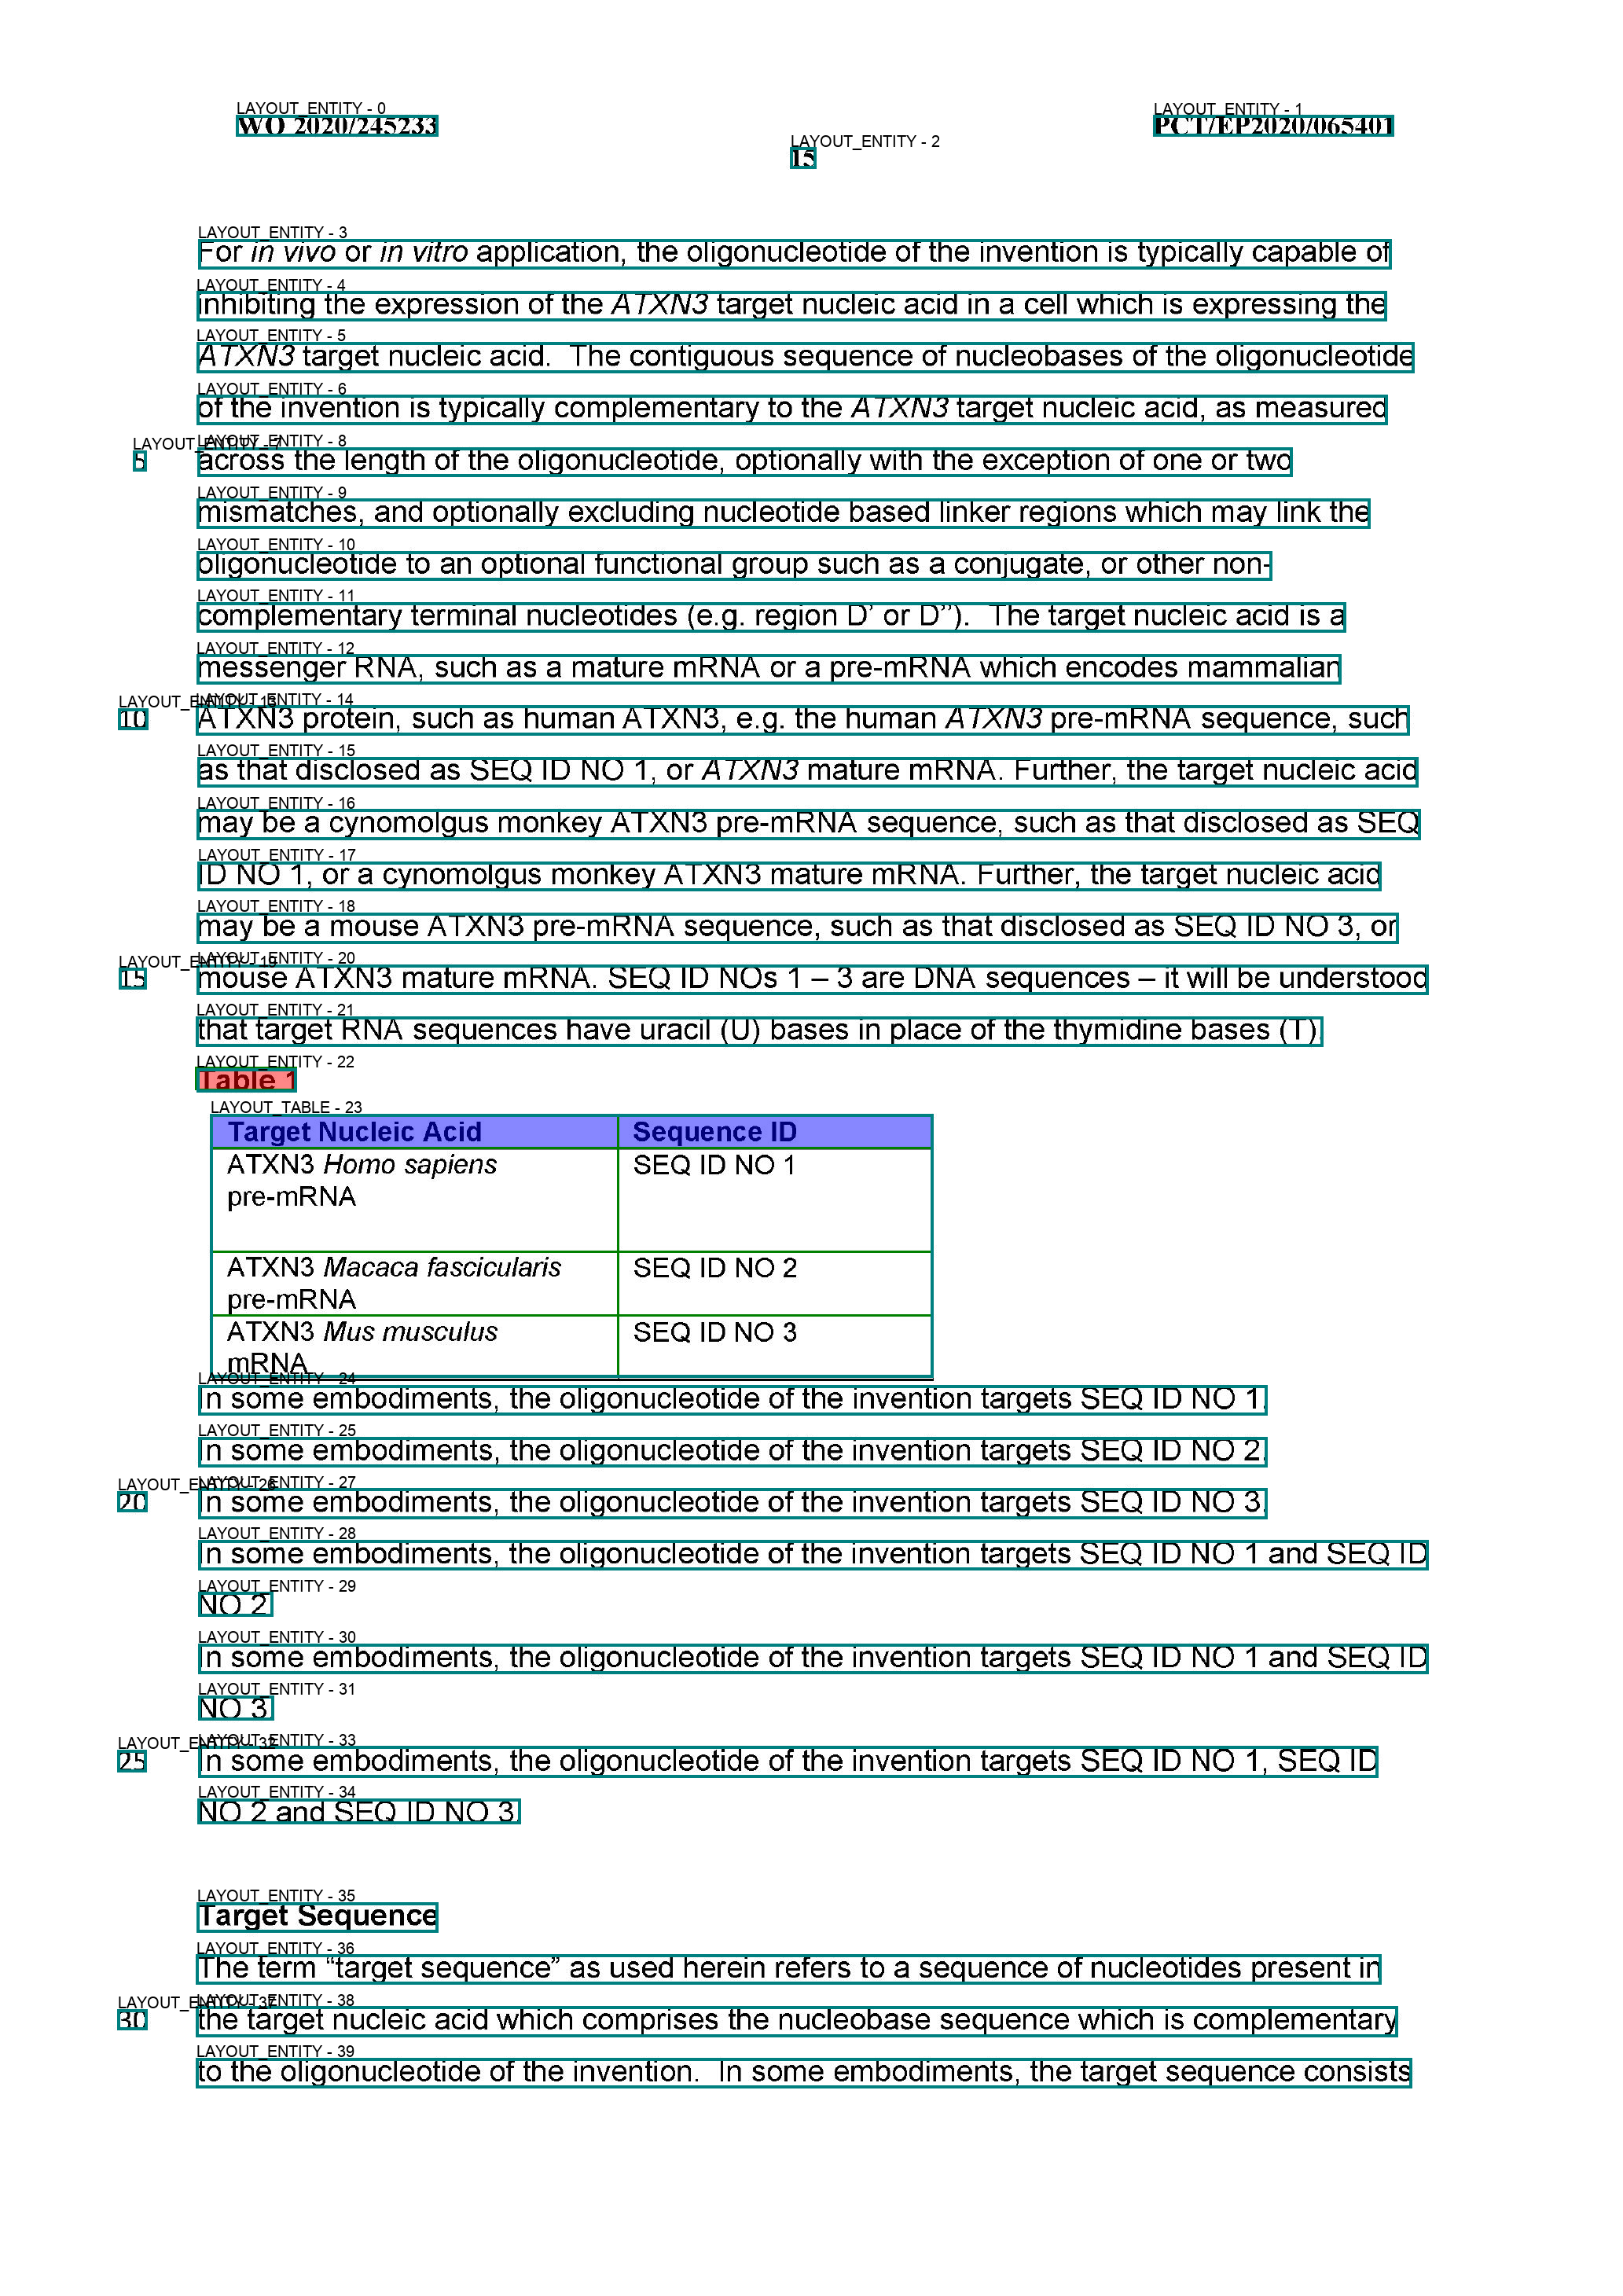

In [ ]:
page = image_document.pages[0]
page.visualize(
    font_size_ratio=1.0, 
    with_text=True,
    with_words=False,
    with_confidence=False
)
